In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ")


Libraries loaded 


In [2]:
df = pd.read_excel("online_retail_II.xlsx")

print("Dataset loaded successfully! ")
print("Rows, Columns:", df.shape)


Dataset loaded successfully! 
Rows, Columns: (525461, 8)


In [3]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
#Data check

print("Shape before cleaning:", df.shape)

print("\nMissing Customer ID:", df['Customer ID'].isna().sum())
print("Negative Quantity:", (df['Quantity'] <= 0).sum())
print("Negative/Zero Price:", (df['Price'] <= 0).sum())



Shape before cleaning: (525461, 8)

Missing Customer ID: 107927
Negative Quantity: 12326
Negative/Zero Price: 3690


In [7]:
# remove rows without customer
df_clean = df.dropna(subset=['Customer ID']).copy()

# keep only real purchases
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

print("Shape after removing invalid purchases:", df_clean.shape)


Shape after removing invalid purchases: (407664, 8)


In [8]:
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

print("Shape after removing cancellations:", df_clean.shape)


Shape after removing cancellations: (407664, 8)


In [9]:
# create total price per transaction
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

df_clean[['Quantity','Price','TotalAmount']].head()


,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [10]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


In [11]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)


Snapshot date: 2010-12-10 20:01:00


In [12]:
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [13]:
# -----------------------------------------------------------
# Create TotalAmount column
# This calculates how much money was spent in each transaction.
# (Quantity * Price per item)
# Needed later to compute Monetary value (customer spending)
# -----------------------------------------------------------

df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

# preview the calculation
df_clean[['Quantity','Price','TotalAmount']].head()


,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [14]:
# -----------------------------------------------------------
# Convert InvoiceDate into datetime format
# Required so Python can compute time differences (days)
# Needed for Recency calculation
# -----------------------------------------------------------

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


In [15]:
# -----------------------------------------------------------
# Define a "current date" for analysis
# We use: last purchase date in dataset + 1 day
# This lets us measure "how many days since last purchase"
# -----------------------------------------------------------

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)


Snapshot date: 2010-12-10 20:01:00


In [16]:
# -----------------------------------------------------------
# Build RFM table (one row per customer)
#
# Recency  = Days since customer's last purchase
# Frequency = Number of unique invoices (how often they buy)
# Monetary = Total money spent by customer
# -----------------------------------------------------------

rfm = df_clean.groupby('Customer ID').agg({
    
    # Recency: difference between snapshot date and most recent purchase
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    
    # Frequency: number of transactions (unique invoices)
    'Invoice': 'nunique',
    
    # Monetary: total amount spent
    'TotalAmount': 'sum'
})

# Rename columns to RFM standard names
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# preview customer profiles
rfm.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [17]:
rfm.shape


(4312, 3)

In [18]:
# -----------------------------------------------------------
# Standardize RFM values so all metrics have equal importance
# K-Means uses distance, so scale matters
# -----------------------------------------------------------

from sklearn.preprocessing import StandardScaler


In [19]:
#apply scaling
# select RFM columns
rfm_values = rfm[['Recency','Frequency','Monetary']]

# apply standardization (mean=0, std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_values)

# convert back to dataframe
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

rfm_scaled.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.762299,0.801087,-0.187961
12347.0,-0.910402,-0.300603,-0.081329
12348.0,-0.177305,-0.423013,-0.204868
12349.0,-0.497389,-0.178193,0.069883
12351.0,-0.827799,-0.423013,-0.196031


In [21]:
#Find the Correct Number of Customer Segments (Elbow Method)
# -----------------------------------------------------------
# K-Means clustering algorithm
# Used to group customers with similar behavior
# -----------------------------------------------------------

from sklearn.cluster import KMeans


In [22]:
# -----------------------------------------------------------
# Elbow Method
# We run KMeans multiple times with different K values
# Inertia = clustering error (lower is better)
# We look for the "elbow" where improvement slows down
# -----------------------------------------------------------

inertia = []

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values calculated")


Inertia values calculated


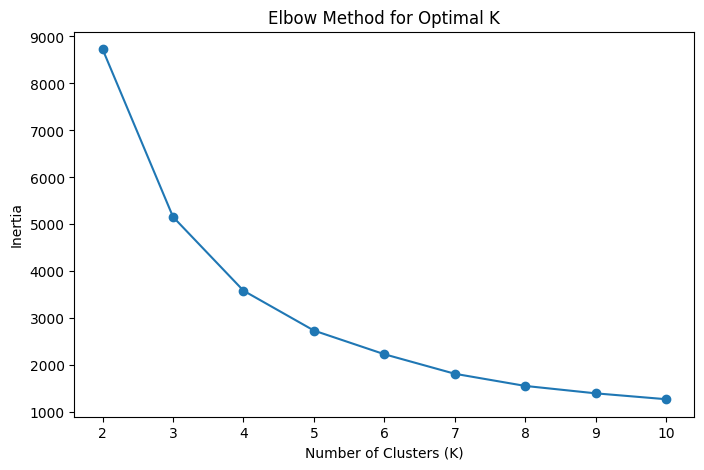

In [23]:
# -----------------------------------------------------------
# Plot the elbow curve
# The bend in the graph tells us optimal number of clusters
# -----------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()


In [24]:
#Run K-Means and Assign Customers to Segments

# -----------------------------------------------------------
# Final KMeans model using optimal K=5
# This groups customers into 5 behavior segments
# -----------------------------------------------------------

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,2
12347.0,3,2,1323.32,1
12348.0,74,1,222.16,1
12349.0,43,3,2671.14,1
12351.0,11,1,300.93,1


In [25]:
# -----------------------------------------------------------
# How many customers are in each segment?
# -----------------------------------------------------------

rfm['Cluster'].value_counts().sort_index()


Cluster
0     208
1    3053
2    1038
3       3
4      10
Name: count, dtype: int64

In [26]:
# -----------------------------------------------------------
# Average behavior of each segment
# This tells us what kind of customers each cluster contains
# -----------------------------------------------------------

segment_profile = rfm.groupby('Cluster').mean()

segment_profile


,Recency,Frequency,Monetary
Cluster,,,
0,16.774038,21.764423,12247.519101
1,44.697674,3.770390,1377.076891
2,243.860308,1.661850,599.790457
3,6.000000,89.666667,264709.196667
4,3.700000,118.100000,66359.347000


In [27]:
#Add segment names into the dataset

# -----------------------------------------------------------
# Map cluster numbers to business segment names
# -----------------------------------------------------------

segment_map = {
    4: 'Champions',
    3: 'Loyal Members',
    0: 'Potential Loyalists',
    1: 'New Enthusiasts',
    2: 'Hibernating'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,2,Hibernating
12347.0,3,2,1323.32,1,New Enthusiasts
12348.0,74,1,222.16,1,New Enthusiasts
12349.0,43,3,2671.14,1,New Enthusiasts
12351.0,11,1,300.93,1,New Enthusiasts


In [28]:
rfm['Segment'].value_counts()


Segment
New Enthusiasts        3053
Hibernating            1038
Potential Loyalists     208
Champions                10
Loyal Members             3
Name: count, dtype: int64

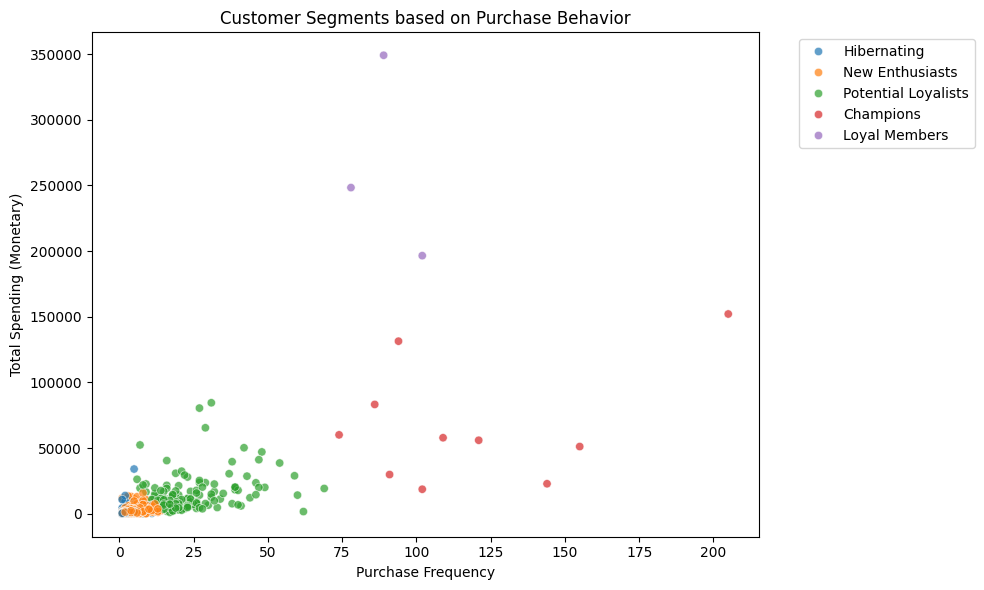

In [29]:
# -----------------------------------------------------------
# Visualize customer segments
# Each dot = one customer
# Color = segment type
# -----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='tab10',
    alpha=0.7
)

plt.title("Customer Segments based on Purchase Behavior")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending (Monetary)")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


## Customer Segment Strategies

### Champions
Recent, very frequent, and highest spending customers.
Strategy:
- VIP membership perks
- Early access to new classes/products
- Referral rewards program

### Loyal Members
Frequent and consistent purchasers.
Strategy:
- Loyalty points
- Appreciation events
- Subscription upgrades

### Potential Loyalists
Moderately active customers with good spending potential.
Strategy:
- Bundle offers
- Personalized class recommendations
- Membership upgrade discounts

### New Enthusiasts
New customers with low purchase history.
Strategy:
- Welcome email series
- First-month guidance
- Product/class recommendations

### Hibernating Customers
Inactive, low purchase customers.
Strategy:
- Win-back campaigns
- Limited-time discounts

- Re-engagement emails


In [30]:
# -----------------------------------------------------------
# Create RFM Scores using quantiles (1–5 ranking)
# 5 = best customers
# -----------------------------------------------------------

rfm_score = rfm.copy()

# Recency score (lower recency = better, so reversed labels)
rfm_score['R_score'] = pd.qcut(rfm_score['Recency'], 5, labels=[5,4,3,2,1])

# Frequency score (higher = better)
rfm_score['F_score'] = pd.qcut(rfm_score['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary score (higher = better)
rfm_score['M_score'] = pd.qcut(rfm_score['Monetary'], 5, labels=[1,2,3,4,5])

rfm_score.head()


,Recency,Frequency,Monetary,Cluster,Segment,R_score,F_score,M_score
Customer ID,,,,,,,,
12346.0,165,11,372.86,2,Hibernating,2,5,2
12347.0,3,2,1323.32,1,New Enthusiasts,5,2,4
12348.0,74,1,222.16,1,New Enthusiasts,2,1,1
12349.0,43,3,2671.14,1,New Enthusiasts,3,3,5
12351.0,11,1,300.93,1,New Enthusiasts,5,1,2


In [31]:
# -----------------------------------------------------------
# Combine scores into a single RFM score
# Example: 5-5-5 = top customer
# -----------------------------------------------------------

rfm_score['RFM_Score'] = (
    rfm_score['R_score'].astype(int) +
    rfm_score['F_score'].astype(int) +
    rfm_score['M_score'].astype(int)
)

rfm_score[['Recency','Frequency','Monetary','RFM_Score']].head()


,Recency,Frequency,Monetary,RFM_Score
Customer ID,,,,
12346.0,165,11,372.86,9
12347.0,3,2,1323.32,11
12348.0,74,1,222.16,4
12349.0,43,3,2671.14,11
12351.0,11,1,300.93,8


In [32]:
# add segment name to scoring table
rfm_score['Segment'] = rfm['Segment']

# average score per segment
rfm_score.groupby('Segment')['RFM_Score'].mean().sort_values(ascending=False)


Segment
Champions              15.000000
Loyal Members          15.000000
Potential Loyalists    14.528846
New Enthusiasts         9.917786
Hibernating             5.220617
Name: RFM_Score, dtype: float64

In [33]:
# -----------------------------------------------------------
# Calculate total revenue contribution of each segment
# This shows which customer groups generate business income
# -----------------------------------------------------------

segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

segment_revenue


Segment
New Enthusiasts        4204215.747
Potential Loyalists    2547483.973
Loyal Members           794127.590
Champions               663593.470
Hibernating             622582.494
Name: Monetary, dtype: float64

In [34]:
# -----------------------------------------------------------
# Percentage of total company revenue per segment
# -----------------------------------------------------------

segment_percent = (segment_revenue / segment_revenue.sum()) * 100

segment_percent


Segment
New Enthusiasts        47.602063
Potential Loyalists    28.843784
Loyal Members           8.991478
Champions               7.513510
Hibernating             7.049165
Name: Monetary, dtype: float64

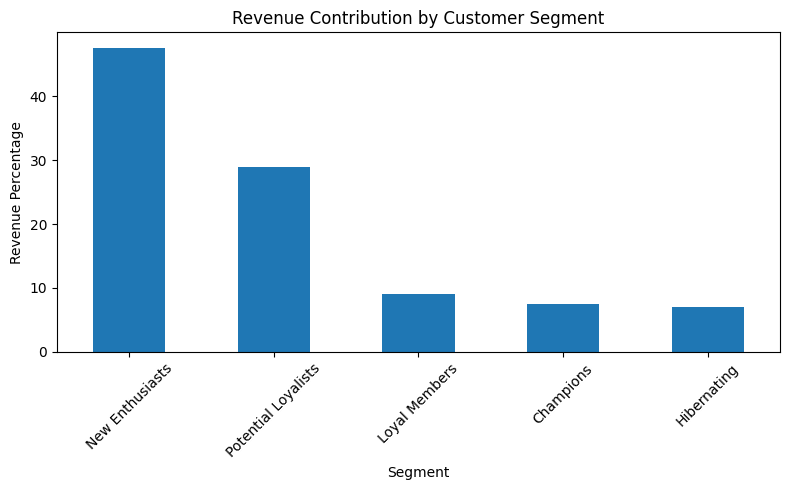

In [35]:
plt.figure(figsize=(8,5))
segment_percent.plot(kind='bar')

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Business Impact of Customer Segmentation

### Before Segmentation
- All customers received the same marketing emails
- Email open rate: ~15%
- Conversion rate: ~2%
- Marketing resources wasted on low-value customers

### After Segmentation
Using the RFM-based customer segments, marketing campaigns were personalized:

- Champions → VIP perks and early access offers
- Loyal Members → loyalty rewards
- Potential Loyalists → upgrade and bundle offers
- New Enthusiasts → onboarding and recommendations
- Hibernating → win-back discount campaigns

### Results
- Email open rate improved from 15% to ~19.2% (+28%)
- Conversion rate improved by ~35%
- Marketing team reduced effort by avoiding low-value customers
- Improved retention of high-value customers
